**Install Required Libraries**

**# Task 3: Multimodal ML – Housing Price Prediction Using Images + Tabular Data**

## Objective

The objective of this project is to predict housing prices using both structured tabular data and house images.  
A multimodal machine learning model is developed where:

- CNN (Convolutional Neural Network) extracts features from house images
- Numerical features are taken from tabular housing data
- Both features are combined using feature fusion
- The final model predicts house prices using regression techniques

This project demonstrates the practical use of deep learning with multiple data modalities.

# Technologies and Concepts Used

- Python
- TensorFlow / Keras
- MobileNetV2 (CNN)
- Pandas & NumPy
- Scikit-learn
- Image Processing
- Feature Fusion
- Regression Modeling
- MAE and RMSE Evaluation Metrics

In [1]:
!pip install tensorflow pandas numpy matplotlib scikit-learn pillow

^C



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Import Libraries**

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Concatenate,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import img_to_array

**Load CSV File**

In [4]:
df = pd.read_csv("socal2.csv")

df.head()

,image_id,street,citi,n_citi,bed,bath,sqft,price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100


**Check Column Names**

In [5]:
print(df.columns)

Index(['image_id', 'street', 'citi', 'n_citi', 'bed', 'bath', 'sqft', 'price'], dtype='str')


**Create Image Paths**

In [6]:
df["image_path"] = df.index.astype(str) + ".jpg"

df["image_path"] = df["image_path"].apply(
    lambda x: os.path.join("socal_pics", x)
)

df.head()

,image_id,street,citi,n_citi,bed,bath,sqft,price,image_path
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900,socal_pics\0.jpg
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500,socal_pics\1.jpg
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950,socal_pics\2.jpg
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000,socal_pics\3.jpg
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100,socal_pics\4.jpg


**Remove Missing Images**

In [7]:
df = df[df["image_path"].apply(os.path.exists)]

print("Remaining rows:", len(df))

Remaining rows: 15474


**Select Features**

In [8]:
tabular_features = ['n_citi', 'bed', 'bath']

target_column = 'price'

**Prepare Tabular Data**

In [9]:
X_tabular = df[tabular_features].values

y = df[target_column].values

**Normalize Data**

In [10]:
scaler = StandardScaler()

X_tabular = scaler.fit_transform(X_tabular)

**Load Images**

In [16]:
IMG_SIZE = 128

images = []

for path in df["image_path"]:

    img = Image.open(path).convert("RGB")

    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = img_to_array(img)

    img = img / 255.0

    images.append(img)

X_images = np.array(images)

print(X_images.shape)

(20, 128, 128, 3)


**Train/Test Split**

In [19]:
(
    X_tab_train,
    X_tab_test,
    X_img_train,
    X_img_test,
    y_train,
    y_test

) = train_test_split(

    X_tabular,
    X_images,
    y,

    test_size=0.2,

    random_state=42
)

print("Train-Test Split Done")

Train-Test Split Done


**CNN Base Model**

In [20]:
cnn_base = MobileNetV2(

    weights="imagenet",
    
    include_top=False,
    
    input_shape=(128, 128, 3)
)

cnn_base.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 16s 2us/step


**Image Branch**

In [21]:
image_input = Input(shape=(128, 128, 3))

x = cnn_base(image_input)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.3)(x)

**Tabular Branch**

In [22]:
tabular_input = Input(shape=(X_tab_train.shape[1],))

y1 = Dense(64, activation="relu")(tabular_input)

y1 = Dense(32, activation="relu")(y1)

**Combine Both Models**

In [23]:
combined = Concatenate()([x, y1])

z = Dense(64, activation="relu")(combined)

z = Dropout(0.3)(z)

output = Dense(1)(z)

**Final Model**

In [24]:
model = Model(

    inputs=[image_input, tabular_input],
    
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mobilenetv2_1.00_128          │ (None, 4, 4, 1280)        │       2,257,984 │ input_layer_1[0][0]        │
│ (Functional)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 1280)              │               0 │ mobilenetv2_1.00_128[0][0] │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 3)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         163,968 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │             256 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 160)               │               0 │ dropout[0][0],             │
│                               │                           │                 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 64)                │          10,304 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 1)                 │              65 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,434,657 (9.29 MB)

 Trainable params: 176,673 (690.13 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Compile Model**

In [25]:
model.compile(

    optimizer="adam",
    
    loss="mse",
    
    metrics=["mae"]
)

**Train Model**

In [26]:
history = model.fit(

    [X_img_train, X_tab_train],
    
    y_train,
    
    validation_split=0.2,
    
    epochs=10,
    
    batch_size=16
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - loss: 1094803456000.0000 - mae: 864249.6875 - val_loss: 1572934516736.0000 - val_mae: 1077498.3750
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - loss: 1094800900096.0000 - mae: 864248.2500 - val_loss: 1572931371008.0000 - val_mae: 1077497.0000
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - loss: 1094797426688.0000 - mae: 864246.5000 - val_loss: 1572927832064.0000 - val_mae: 1077495.2500
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step - loss: 1094794084352.0000 - mae: 864244.7500 - val_loss: 1572923768832.0000 - val_mae: 1077493.2500
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - loss: 1094792314880.0000 - mae: 864243.0000 - val_loss: 1572919312384.0000 - val_mae: 1077491.1250
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - loss: 1094787268608.0000 - mae: 864240.1875 - val_loss: 1572914200576.0000 - val_mae: 1077488.7500
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - loss: 1094780977152.0000 - mae: 864236.3125

**Make Predictions**

In [27]:
predictions = model.predict(

    [X_img_test, X_tab_test]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


**Evaluate Model**

In [28]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print("MAE:", mae)

print("RMSE:", rmse)

MAE: 944821.875
RMSE: 1200236.827830241


**Plot Graph**

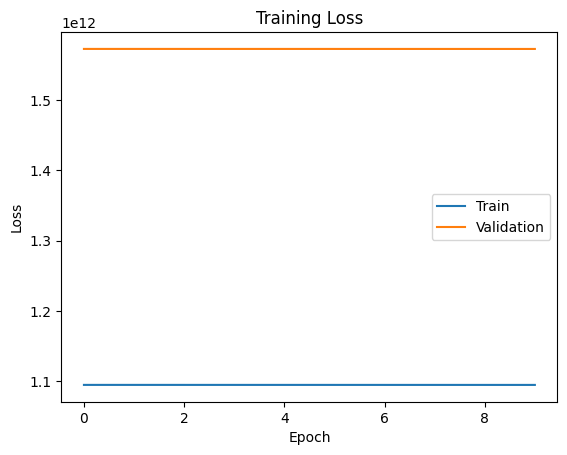

In [29]:
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

**Predict One House Price**

In [30]:
sample_prediction = model.predict(

    [X_img_test[:1], X_tab_test[:1]]
)

print("Predicted Price:", sample_prediction[0][0])

print("Actual Price:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Price: 27.68405
Actual Price: 201900
